# Visualize Moving Bar Spike Trains

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import matplotlib.pyplot as plt
import os

In [2]:
piece = '2013-05-28-3'
analysis_base = f"/Volumes/Analysis/{piece}"

wnoise = "data000"
mbar = "data003"
cell_types = ['ON parasol', 'OFF parasol']

wnoise_path = os.path.join(analysis_base, wnoise)
mbar_path = os.path.join(analysis_base, mbar)

In [3]:
vcd = vl.load_vision_data(mbar_path,mbar,
                        include_neurons=True,
                        # include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

In [4]:
cell_ids = vcd.get_all_cells_similar_to_type("ON parasol")
spike_times = np.array([vcd.get_spike_times_for_cell(c) for c in cell_ids], dtype=object)
spike_times /= 20

print(spike_times.shape)

bin_size_ms = 2.5
sample_size = bin_size_ms * 20 
rounded_spike_times = np.array([np.round(vcd.get_spike_times_for_cell(c) / sample_size) * sample_size for c in cell_ids], dtype=object)
rounded_spike_times /= 20

print(rounded_spike_times.shape)

(6,)
(6,)


In [5]:
low = 0
high = 1000

filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
filtered_rounded_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in rounded_spike_times], dtype=object)

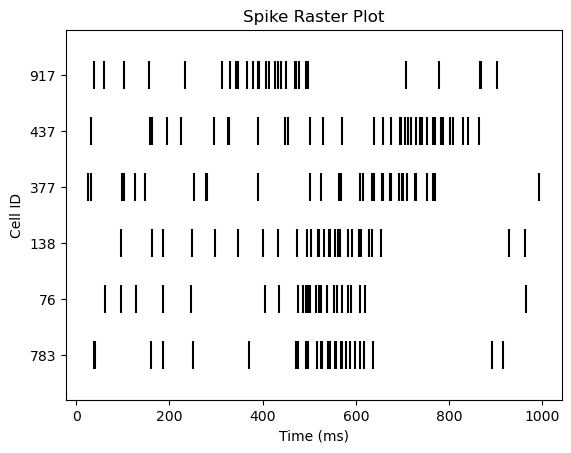

In [6]:
# Create a spike raster plot
plt.eventplot(filtered_spike_times, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Show the plot
plt.show()


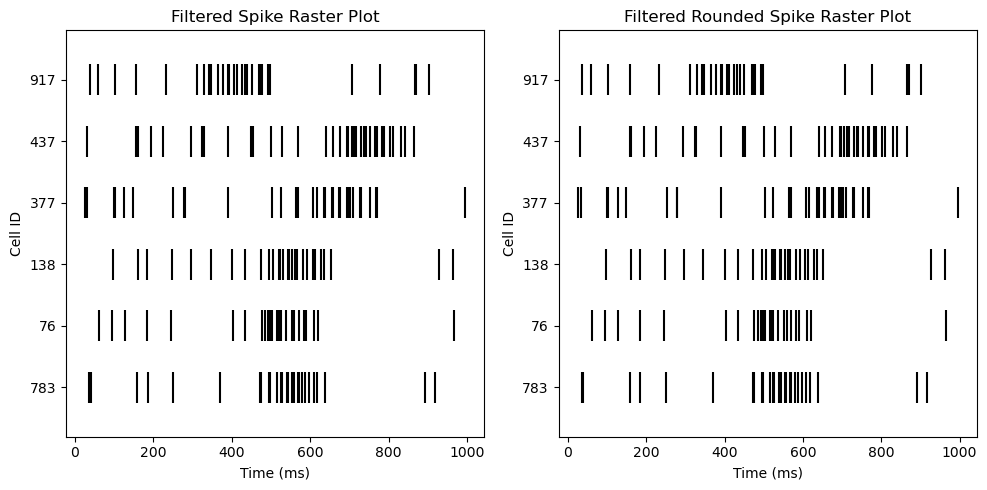

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Change the figsize as desired

# Plot the filtered spike times
axs[0].eventplot(filtered_spike_times, linelengths=0.5, colors='black')
axs[0].set_yticks(range(len(cell_ids)))
axs[0].set_yticklabels(cell_ids)
axs[0].set_ylabel('Cell ID')
axs[0].set_xlabel('Time (ms)')
axs[0].set_title('Filtered Spike Raster Plot')

# Plot the filtered rounded spike times
axs[1].eventplot(filtered_rounded_spike_times, linelengths=0.5, colors='black')
axs[1].set_yticks(range(len(cell_ids)))
axs[1].set_yticklabels(cell_ids)
axs[1].set_ylabel('Cell ID')
axs[1].set_xlabel('Time (ms)')
axs[1].set_title('Filtered Rounded Spike Raster Plot')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

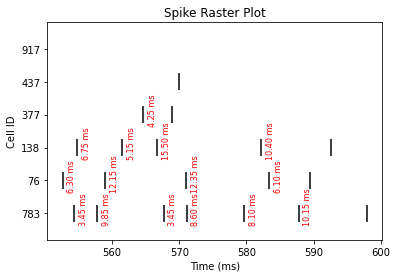

In [15]:
# Create a spike raster plot
plt.eventplot(filtered_spike_times, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        plt.annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Show the plot
plt.show()

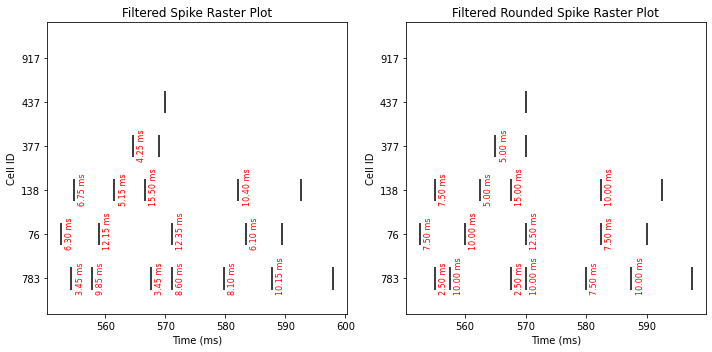

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Change the figsize as desired

# Plot the filtered spike times
axs[0].eventplot(filtered_spike_times, linelengths=0.5, colors='black')
axs[0].set_yticks(range(len(cell_ids)))
axs[0].set_yticklabels(cell_ids)
axs[0].set_ylabel('Cell ID')
axs[0].set_xlabel('Time (ms)')
axs[0].set_title('Filtered Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        axs[0].annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Plot the filtered rounded spike times
axs[1].eventplot(filtered_rounded_spike_times, linelengths=0.5, colors='black')
axs[1].set_yticks(range(len(cell_ids)))
axs[1].set_yticklabels(cell_ids)
axs[1].set_ylabel('Cell ID')
axs[1].set_xlabel('Time (ms)')
axs[1].set_title('Filtered Rounded Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_rounded_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        axs[1].annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

In [10]:
min_interspike_interval = np.array([np.min(np.diff(cell_spike_times)) for cell_spike_times in spike_times])
average_interspike_interval = np.array([np.mean(np.diff(cell_spike_times)) for cell_spike_times in spike_times])
average_spike_rate = np.array([len(cell_spike_times) / (vcd.get_n_samples()/20000) for cell_spike_times in spike_times])

proportions = []
for cell_spike_times in spike_times:
    intervals = np.diff(cell_spike_times)
    proportion = np.mean(intervals < 2.5)
    proportions.append(proportion)
proportions = np.array(proportions)

print("Minimum Interspike Interval:")
print(min_interspike_interval)
print(np.mean(min_interspike_interval))

print("Average Interspike Interval:")
print(average_interspike_interval)
print(np.mean(average_interspike_interval))

print("Percentage of Interspike Intervals < 2.5 ms:")
print(proportions*100)
print(np.mean(proportions)*100)

print("Average Spike Rate:")
print(average_spike_rate)
print(np.mean(average_spike_rate))

Minimum Interspike Interval:
[2.1  1.95 1.85 2.   1.95 1.9 ]
1.9583333333369712
Average Interspike Interval:
[48.81617432 61.09549343 47.60593452 45.59689887 53.55644168 54.85919067]
51.92168891524394
Percentage of Interspike Intervals < 2.5 ms:
[1.35498047 0.76382524 2.03571429 1.63037282 2.45078345 1.35802469]
1.5989501582157566
Average Spike Rate:
[20.4825 16.3675 21.0025 21.93   18.67   18.2275]
19.44666666666667


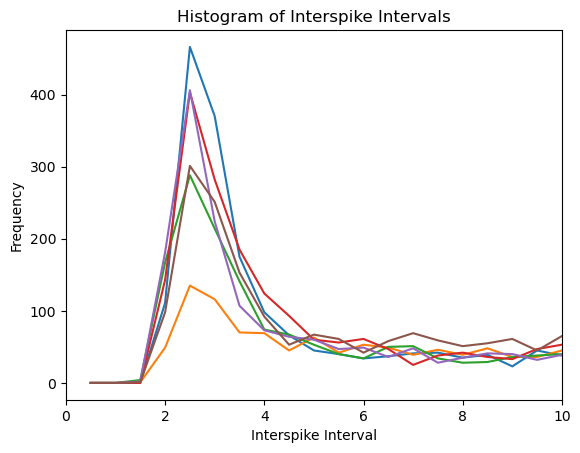

In [11]:
# Calculate the histogram of interspike intervals for each cell
histograms = [np.histogram(np.diff(cell_spike_times), bins=np.arange(1,1000)/2, density=False) for cell_spike_times in spike_times]

# Plot the distribution of interspike intervals for each cell
for histogram in histograms:
    plt.plot(histogram[1][:-1], histogram[0])

# Set the x-axis limits
plt.xlim(0, 10)

# Set the x-axis label
plt.xlabel('Interspike Interval')

# Set the y-axis label
plt.ylabel('Frequency')

# Set the plot title
plt.title('Histogram of Interspike Intervals')

# Show the plot
plt.show()
